# Analyze a TypeScript project with networkx + matplotlib

Notebook version of `examples/analyze_typescript_project.py` with inline graph rendering.

Recommended launch command from the repo root:

`uv run --extra all --group notebook jupyter lab`


In [54]:
from __future__ import annotations

from collections import Counter, defaultdict, deque
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D

from graphlens import NodeKind, RelationKind, adapter_registry

CALLABLE_KINDS = {NodeKind.FUNCTION, NodeKind.METHOD}

project_root = Path("../examples/demo-ts-project")

In [55]:
NODE_COLORS = {
    NodeKind.PROJECT: "#1d4ed8",
    NodeKind.MODULE: "#0891b2",
    NodeKind.FILE: "#0f766e",
    NodeKind.CLASS: "#7c3aed",
    NodeKind.FUNCTION: "#2563eb",
    NodeKind.METHOD: "#4f46e5",
    NodeKind.PARAMETER: "#64748b",
    NodeKind.IMPORT: "#9333ea",
    NodeKind.DEPENDENCY: "#b45309",
    NodeKind.SYMBOL: "#c2410c",
    NodeKind.EXTERNAL_SYMBOL: "#be123c",
}

RELATION_COLORS = {
    RelationKind.CONTAINS: "#0f766e",
    RelationKind.DECLARES: "#1d4ed8",
    RelationKind.IMPORTS: "#9333ea",
    RelationKind.CALLS: "#c2410c",
    RelationKind.REFERENCES: "#7c3aed",
    RelationKind.DEPENDS_ON: "#b45309",
    RelationKind.RESOLVES_TO: "#be123c",
    RelationKind.INHERITS_FROM: "#2563eb",
}

NODE_ORDER = {
    NodeKind.PROJECT: 0,
    NodeKind.MODULE: 1,
    NodeKind.FILE: 2,
    NodeKind.CLASS: 3,
    NodeKind.FUNCTION: 4,
    NodeKind.METHOD: 5,
    NodeKind.PARAMETER: 6,
    NodeKind.IMPORT: 7,
    NodeKind.DEPENDENCY: 8,
    NodeKind.SYMBOL: 9,
    NodeKind.EXTERNAL_SYMBOL: 10,
}


def summarize(graph):
    node_counts = Counter(node.kind.value for node in graph.nodes.values())
    relation_counts = Counter(relation.kind.value for relation in graph.relations)
    print("Nodes:")
    for kind, count in node_counts.most_common():
        print(f"  {kind:<18} {count}")
    print(f"  {'total':<18} {len(graph.nodes)}")
    print("\nRelations:")
    for kind, count in relation_counts.most_common():
        print(f"  {kind:<18} {count}")
    print(f"  {'total':<18} {len(graph.relations)}")


def short_name(node, limit=18):
    value = node.name or node.qualified_name
    return value if len(value) <= limit else value[: limit - 3] + "..."


def list_callables(graph, limit=30):
    names = sorted(
        node.qualified_name
        for node in graph.nodes.values()
        if node.kind in CALLABLE_KINDS
    )
    return names[:limit]


def resolve_callable(graph, query):
    callables = [node for node in graph.nodes.values() if node.kind in CALLABLE_KINDS]
    exact = [node for node in callables if node.qualified_name == query]
    if len(exact) == 1:
        return exact[0]

    exact_name = [node for node in callables if node.name == query]
    if len(exact_name) == 1:
        return exact_name[0]

    lowered = query.lower()
    partial = [node for node in callables if lowered in node.qualified_name.lower()]
    if len(partial) == 1:
        return partial[0]

    matches = exact or exact_name or partial
    if not matches:
        raise ValueError(f"Callable not found: {query}")

    sample = ", ".join(node.qualified_name for node in sorted(matches, key=lambda node: node.qualified_name)[:10])
    raise ValueError(f"Ambiguous callable query '{query}'. Matches: {sample}")


def select_subgraph(graph, relation_kinds=None, node_kinds=None, max_nodes=60):
    allowed_relations = set(relation_kinds) if relation_kinds is not None else None
    allowed_node_kinds = set(node_kinds) if node_kinds is not None else None

    relations = [
        relation
        for relation in graph.relations
        if relation.source_id in graph.nodes
        and relation.target_id in graph.nodes
        and (allowed_relations is None or relation.kind in allowed_relations)
        and (
            allowed_node_kinds is None
            or (
                graph.nodes[relation.source_id].kind in allowed_node_kinds
                and graph.nodes[relation.target_id].kind in allowed_node_kinds
            )
        )
    ]

    if relations:
        node_ids = {relation.source_id for relation in relations} | {
            relation.target_id for relation in relations
        }
        nodes = [graph.nodes[node_id] for node_id in node_ids]
    else:
        nodes = [
            node
            for node in graph.nodes.values()
            if allowed_node_kinds is None or node.kind in allowed_node_kinds
        ]

    degree = Counter()
    for relation in relations:
        degree[relation.source_id] += 1
        degree[relation.target_id] += 1

    nodes.sort(
        key=lambda node: (
            NODE_ORDER.get(node.kind, 99),
            -degree[node.id],
            node.qualified_name,
        )
    )
    nodes = nodes[:max_nodes]
    selected_ids = {node.id for node in nodes}
    relations = [
        relation
        for relation in relations
        if relation.source_id in selected_ids and relation.target_id in selected_ids
    ]
    return nodes, relations


def build_resolution_indexes(graph):
    callables_by_qname = defaultdict(list)
    callables_by_name = defaultdict(list)
    callables_by_file = defaultdict(list)
    imports_by_file = defaultdict(list)
    for node in graph.nodes.values():
        if node.kind in CALLABLE_KINDS:
            callables_by_qname[node.qualified_name].append(node)
            callables_by_name[node.name].append(node)
            if node.file_path:
                callables_by_file[node.file_path].append(node)
        elif node.kind == NodeKind.IMPORT and node.file_path:
            imports_by_file[node.file_path].append(node)
    return callables_by_qname, callables_by_name, callables_by_file, imports_by_file


def resolve_symbol_targets(graph, caller, symbol, indexes):
    callables_by_qname, callables_by_name, callables_by_file, imports_by_file = indexes
    file_path = caller.file_path or ""
    names = [symbol.name]
    if "." in symbol.name:
        names.append(symbol.name.rsplit(".", 1)[-1])

    candidates = []
    for name in names:
        if name in callables_by_qname:
            candidates.extend(callables_by_qname[name])

        for imp in imports_by_file.get(file_path, []):
            original = imp.metadata.get("original_name")
            alias = imp.metadata.get("alias")
            imported_name = str(original).split(".")[-1] if original else None
            if imp.name == name or alias == name or imported_name == name:
                if original:
                    candidates.extend(callables_by_qname.get(str(original), []))

        for node in callables_by_file.get(file_path, []):
            if node.name == name:
                candidates.append(node)

        if len(callables_by_name.get(name, [])) == 1:
            candidates.extend(callables_by_name[name])

    resolved = []
    seen = set()
    for node in candidates:
        if node.id not in seen:
            seen.add(node.id)
            resolved.append(node)
    return resolved


def make_call_relation(source_id, target_id):
    return SimpleNamespace(source_id=source_id, target_id=target_id, kind=RelationKind.CALLS)


def build_resolved_call_relations(graph):
    indexes = build_resolution_indexes(graph)
    resolved = []
    seen = set()
    for relation in graph.relations:
        if relation.kind != RelationKind.CALLS:
            continue
        if relation.source_id not in graph.nodes or relation.target_id not in graph.nodes:
            continue

        source = graph.nodes[relation.source_id]
        target = graph.nodes[relation.target_id]
        if source.kind not in CALLABLE_KINDS:
            continue

        targets = []
        if target.kind in CALLABLE_KINDS:
            targets = [target]
        elif target.kind == NodeKind.SYMBOL:
            targets = resolve_symbol_targets(graph, source, target, indexes)

        for resolved_target in targets:
            key = (source.id, resolved_target.id)
            if key not in seen:
                seen.add(key)
                resolved.append(make_call_relation(*key))
    return resolved


def select_resolved_call_subgraph(graph, max_nodes=50):
    relations = build_resolved_call_relations(graph)
    degree = Counter()
    node_ids = set()
    for relation in relations:
        degree[relation.source_id] += 1
        degree[relation.target_id] += 1
        node_ids.add(relation.source_id)
        node_ids.add(relation.target_id)

    if node_ids:
        nodes = [graph.nodes[node_id] for node_id in node_ids]
    else:
        nodes = [node for node in graph.nodes.values() if node.kind in CALLABLE_KINDS]

    nodes.sort(key=lambda node: (-degree[node.id], node.qualified_name))
    nodes = nodes[:max_nodes]
    selected_ids = {node.id for node in nodes}
    relations = [
        relation
        for relation in relations
        if relation.source_id in selected_ids and relation.target_id in selected_ids
    ]
    return nodes, relations


def compute_levels(nodes, relations):
    node_ids = {node.id for node in nodes}
    outgoing = defaultdict(list)
    incoming = Counter()
    for relation in relations:
        if relation.source_id in node_ids and relation.target_id in node_ids:
            outgoing[relation.source_id].append(relation.target_id)
            incoming[relation.target_id] += 1

    roots = [node.id for node in nodes if node.kind == NodeKind.PROJECT]
    roots.extend(node.id for node in nodes if incoming[node.id] == 0 and node.id not in roots)
    if not roots and nodes:
        roots = [nodes[0].id]

    levels = {}
    queue = deque((root, 0) for root in roots)
    while queue:
        node_id, level = queue.popleft()
        current = levels.get(node_id)
        if current is not None and current <= level:
            continue
        levels[node_id] = level
        for target_id in outgoing.get(node_id, []):
            queue.append((target_id, level + 1))

    next_level = max(levels.values(), default=-1) + 1
    for node in nodes:
        if node.id not in levels:
            levels[node.id] = next_level
            next_level += 1
    return levels


def build_nx_graph(nodes, relations):
    levels = compute_levels(nodes, relations)
    graph_nx = nx.DiGraph()
    for node in nodes:
        graph_nx.add_node(
            node.id,
            label=short_name(node),
            kind=node.kind,
            subset=levels[node.id],
        )
    for relation in relations:
        graph_nx.add_edge(relation.source_id, relation.target_id, kind=relation.kind)
    return graph_nx


def draw_graph(graph, nodes, relations, title, layout="layered", figsize=(15, 9), highlight_node_ids=None):
    if not nodes:
        print(f"{title}: no nodes to draw")
        return

    highlight_node_ids = set(highlight_node_ids or ())
    graph_nx = build_nx_graph(nodes, relations)
    if layout == "spring":
        pos = nx.spring_layout(graph_nx, seed=7, k=max(0.75, 2.2 / max(len(nodes), 1) ** 0.5))
    elif graph_nx.number_of_edges() == 0:
        pos = nx.circular_layout(graph_nx, scale=2.0)
    else:
        pos = nx.multipartite_layout(graph_nx, subset_key="subset", align="vertical", scale=2.4)
        pos = {node_id: (coords[0], -coords[1]) for node_id, coords in pos.items()}

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("#f8fafc")
    ax.set_facecolor("#f8fafc")

    node_colors = [NODE_COLORS.get(graph.nodes[node_id].kind, "#475569") for node_id in graph_nx.nodes]
    node_sizes = []
    node_edgecolors = []
    node_linewidths = []
    for node_id in graph_nx.nodes:
        node = graph.nodes[node_id]
        size = 2400 if node.kind in {NodeKind.PROJECT, NodeKind.MODULE, NodeKind.CLASS} else 1900
        if node_id in highlight_node_ids:
            size += 700
            node_edgecolors.append("#facc15")
            node_linewidths.append(2.8)
        else:
            node_edgecolors.append("white")
            node_linewidths.append(1.2)
        node_sizes.append(size)

    edge_colors = [RELATION_COLORS.get(graph_nx.edges[edge]["kind"], "#64748b") for edge in graph_nx.edges]
    labels = {node.id: short_name(node) for node in nodes}

    nx.draw_networkx_edges(
        graph_nx,
        pos,
        ax=ax,
        edge_color=edge_colors,
        width=1.8,
        alpha=0.72,
        arrowstyle="-|>",
        arrowsize=18,
        connectionstyle="arc3,rad=0.08",
    )
    nx.draw_networkx_nodes(
        graph_nx,
        pos,
        ax=ax,
        node_color=node_colors,
        node_size=node_sizes,
        edgecolors=node_edgecolors,
        linewidths=node_linewidths,
    )
    nx.draw_networkx_labels(
        graph_nx,
        pos,
        labels=labels,
        ax=ax,
        font_size=9,
        font_color="white",
        font_weight="bold",
    )

    node_handles = [
        Line2D([0], [0], marker="o", color="w", label=kind.value, markerfacecolor=color, markersize=9)
        for kind, color in NODE_COLORS.items()
        if any(node.kind == kind for node in nodes)
    ]
    edge_handles = [
        Line2D([0], [0], color=color, lw=2, label=kind.value)
        for kind, color in RELATION_COLORS.items()
        if any(relation.kind == kind for relation in relations)
    ]
    if highlight_node_ids:
        node_handles.append(
            Line2D([0], [0], marker="o", color="w", label="focus", markerfacecolor="#334155", markeredgecolor="#facc15", markeredgewidth=2.0, markersize=9)
        )
    if node_handles or edge_handles:
        ax.legend(handles=node_handles + edge_handles, loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)

    ax.set_title(title, fontsize=16, pad=18)
    ax.text(
        0.01,
        1.02,
        f"nodes={len(nodes)} | relations={len(relations)}",
        transform=ax.transAxes,
        fontsize=10,
        color="#334155",
    )
    ax.axis("off")
    plt.tight_layout()
    plt.show()


def plot_graph(graph, title, relation_kinds=None, node_kinds=None, max_nodes=60, figsize=(15, 9), layout="layered"):
    nodes, relations = select_subgraph(
        graph,
        relation_kinds=relation_kinds,
        node_kinds=node_kinds,
        max_nodes=max_nodes,
    )
    draw_graph(graph, nodes, relations, title=title, layout=layout, figsize=figsize)


def plot_call_graph(graph, title="Call graph", max_nodes=50, figsize=(15, 9)):
    nodes, relations = select_resolved_call_subgraph(graph, max_nodes=max_nodes)
    draw_graph(graph, nodes, relations, title=title, layout="spring", figsize=figsize)


def build_call_neighborhood(graph, function_query, depth=2, include_callers=True, include_callees=True):
    root = resolve_callable(graph, function_query)
    call_relations = build_resolved_call_relations(graph)

    outgoing = defaultdict(set)
    incoming = defaultdict(set)
    for relation in call_relations:
        outgoing[relation.source_id].add(relation.target_id)
        incoming[relation.target_id].add(relation.source_id)

    selected_ids = {root.id}
    frontier = {root.id}
    for _ in range(max(depth, 0)):
        next_frontier = set()
        for node_id in frontier:
            if include_callees:
                next_frontier.update(outgoing.get(node_id, ()))
            if include_callers:
                next_frontier.update(incoming.get(node_id, ()))
        next_frontier -= selected_ids
        if not next_frontier:
            break
        selected_ids.update(next_frontier)
        frontier = next_frontier

    nodes = [graph.nodes[node_id] for node_id in selected_ids]
    relations = [
        relation
        for relation in call_relations
        if relation.source_id in selected_ids and relation.target_id in selected_ids
    ]
    return root, nodes, relations


def plot_call_neighborhood(graph, function_query, depth=2, include_callers=True, include_callees=True, figsize=(13, 9)):
    root, nodes, relations = build_call_neighborhood(
        graph,
        function_query=function_query,
        depth=depth,
        include_callers=include_callers,
        include_callees=include_callees,
    )
    draw_graph(
        graph,
        nodes,
        relations,
        title=f"Call neighborhood: {root.qualified_name}",
        layout="spring",
        figsize=figsize,
        highlight_node_ids={root.id},
    )


In [56]:
adapter = adapter_registry.load("typescript")()
if not adapter.can_handle(project_root):
    raise RuntimeError(f"Not a TypeScript project: {project_root}")

graph = adapter.analyze(project_root)
print(f"Nodes: {len(graph.nodes)}")
print(f"Relations: {len(graph.relations)}")


Nodes: 49
Relations: 58


In [57]:
summarize(graph)


Nodes:
  symbol             9
  import             8
  external_symbol    8
  method             6
  class              4
  parameter          4
  module             3
  file               3
  function           3
  project            1
  total              49

Relations:
  declares           25
  calls              9
  imports            8
  resolves_to        8
  contains           6
  inherits_from      2
  total              58


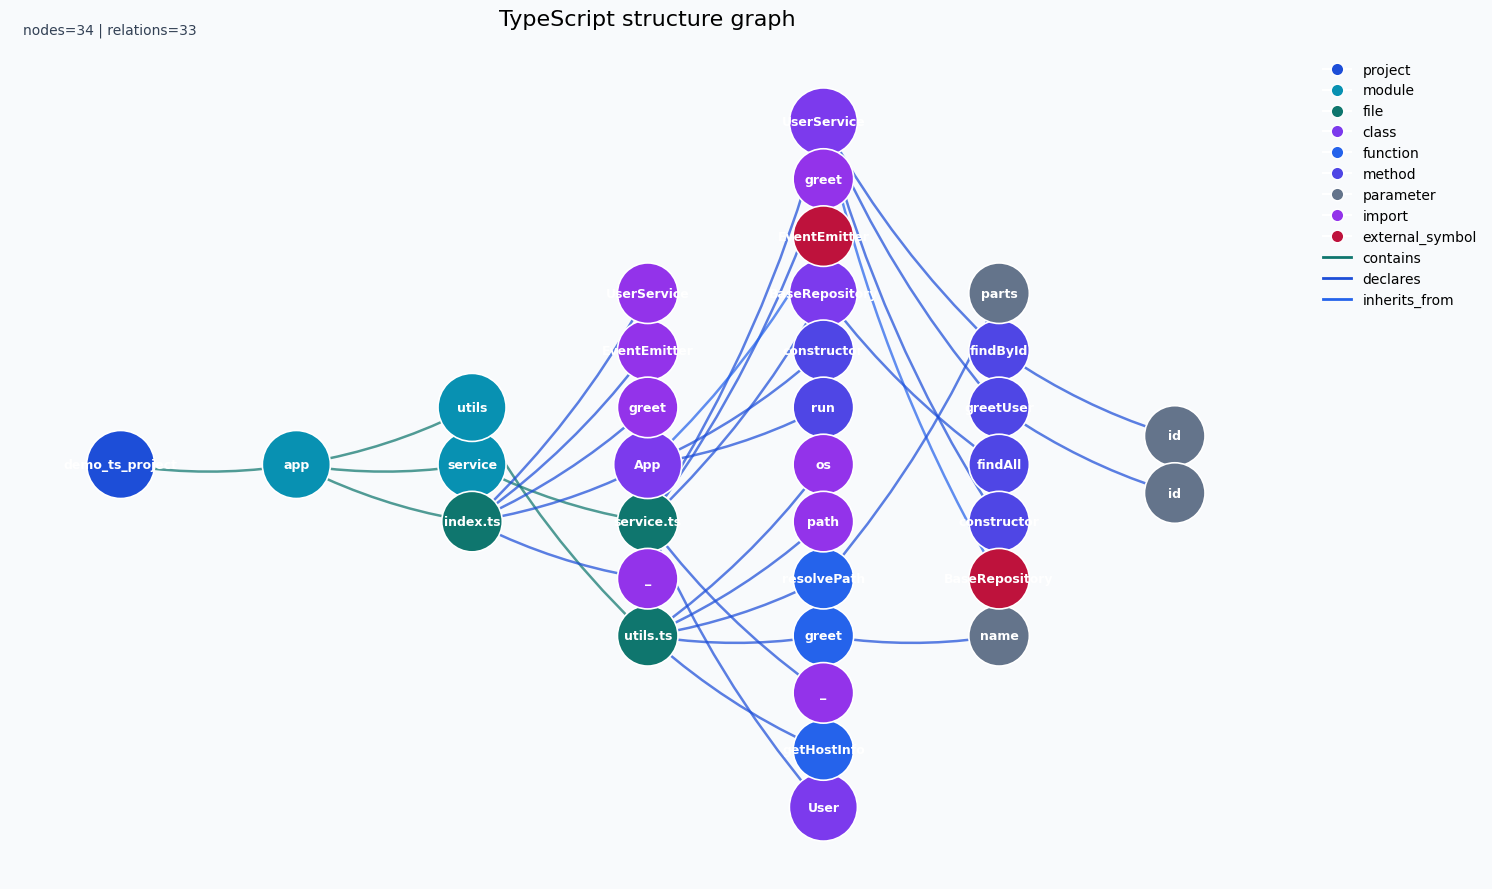

In [58]:
plot_graph(
    graph,
    title="TypeScript structure graph",
    relation_kinds={RelationKind.CONTAINS, RelationKind.DECLARES, RelationKind.INHERITS_FROM},
    max_nodes=70,
)


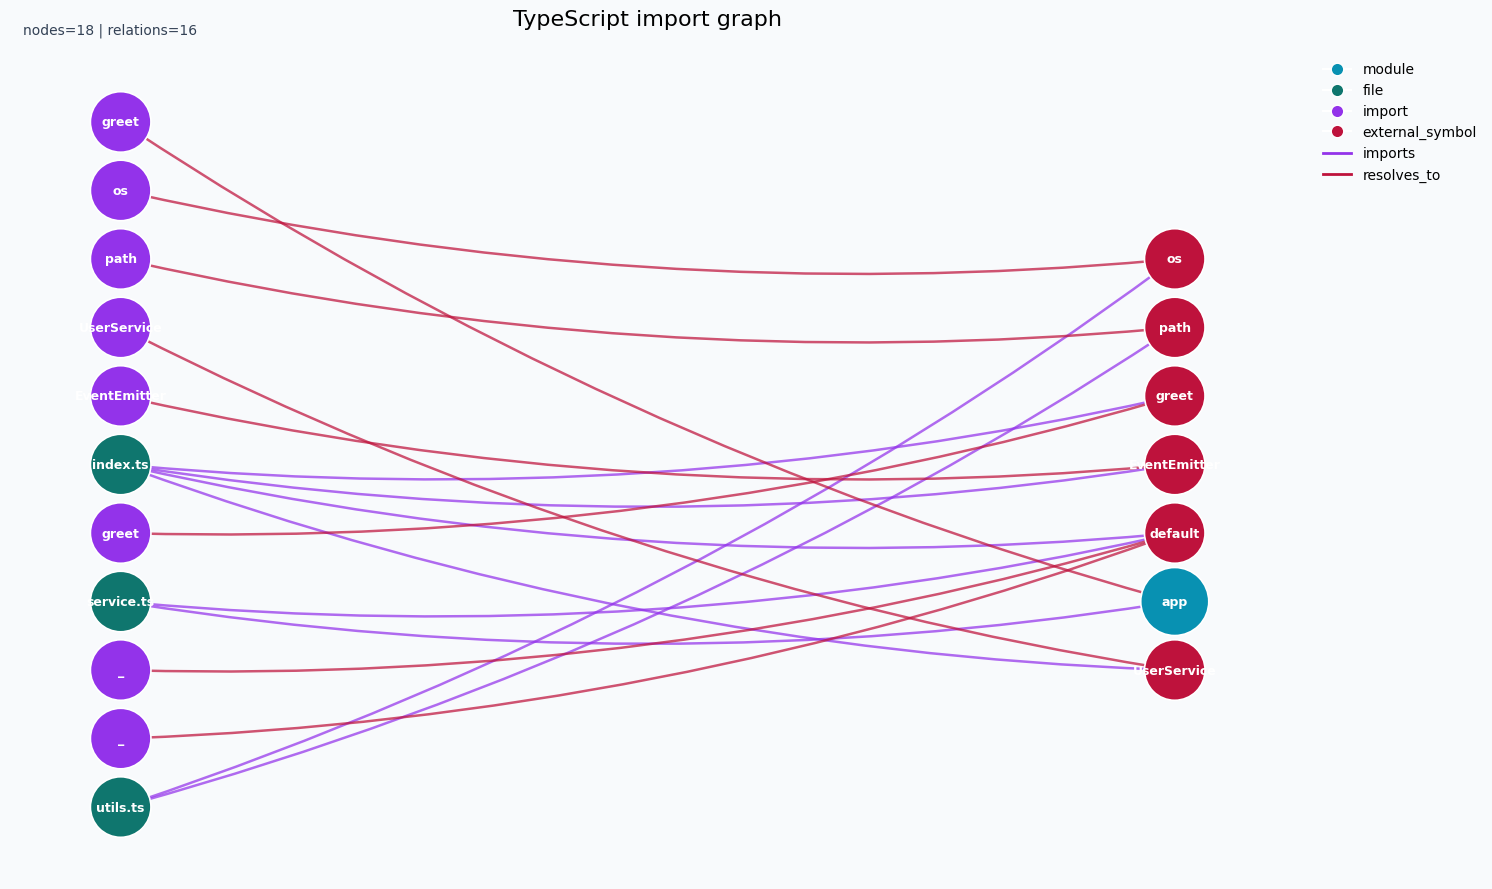

In [59]:
plot_graph(
    graph,
    title="TypeScript import graph",
    relation_kinds={RelationKind.IMPORTS, RelationKind.RESOLVES_TO},
    node_kinds={NodeKind.FILE, NodeKind.IMPORT, NodeKind.MODULE, NodeKind.EXTERNAL_SYMBOL},
    max_nodes=60,
)


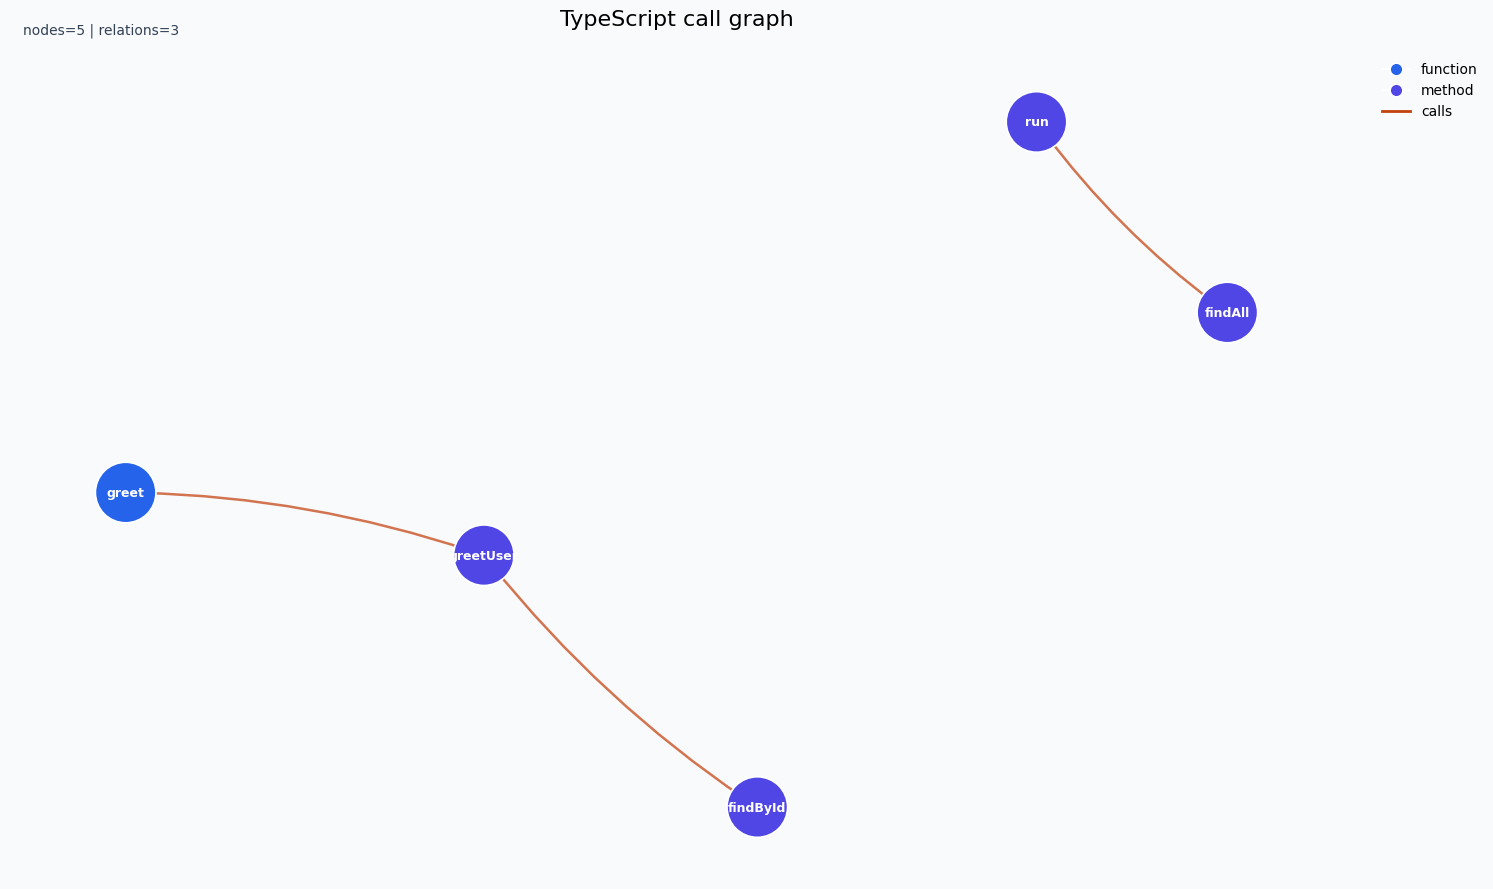

In [60]:
plot_call_graph(
    graph,
    title="TypeScript call graph",
    max_nodes=50,
)


In [61]:
print("Callable preview:")
for name in list_callables(graph, limit=20):
    print(f"  {name}")


Callable preview:
  app.App.constructor
  app.App.run
  app.service.BaseRepository.findAll
  app.service.UserService.constructor
  app.service.UserService.findById
  app.service.UserService.greetUser
  app.utils.getHostInfo
  app.utils.greet
  app.utils.resolvePath


In [62]:
focus_candidates = list_callables(graph, limit=1)
focus_function = focus_candidates[0] if focus_candidates else ""
focus_depth = 2
include_callers = True
include_callees = True

focus_function, focus_depth


('app.App.constructor', 2)

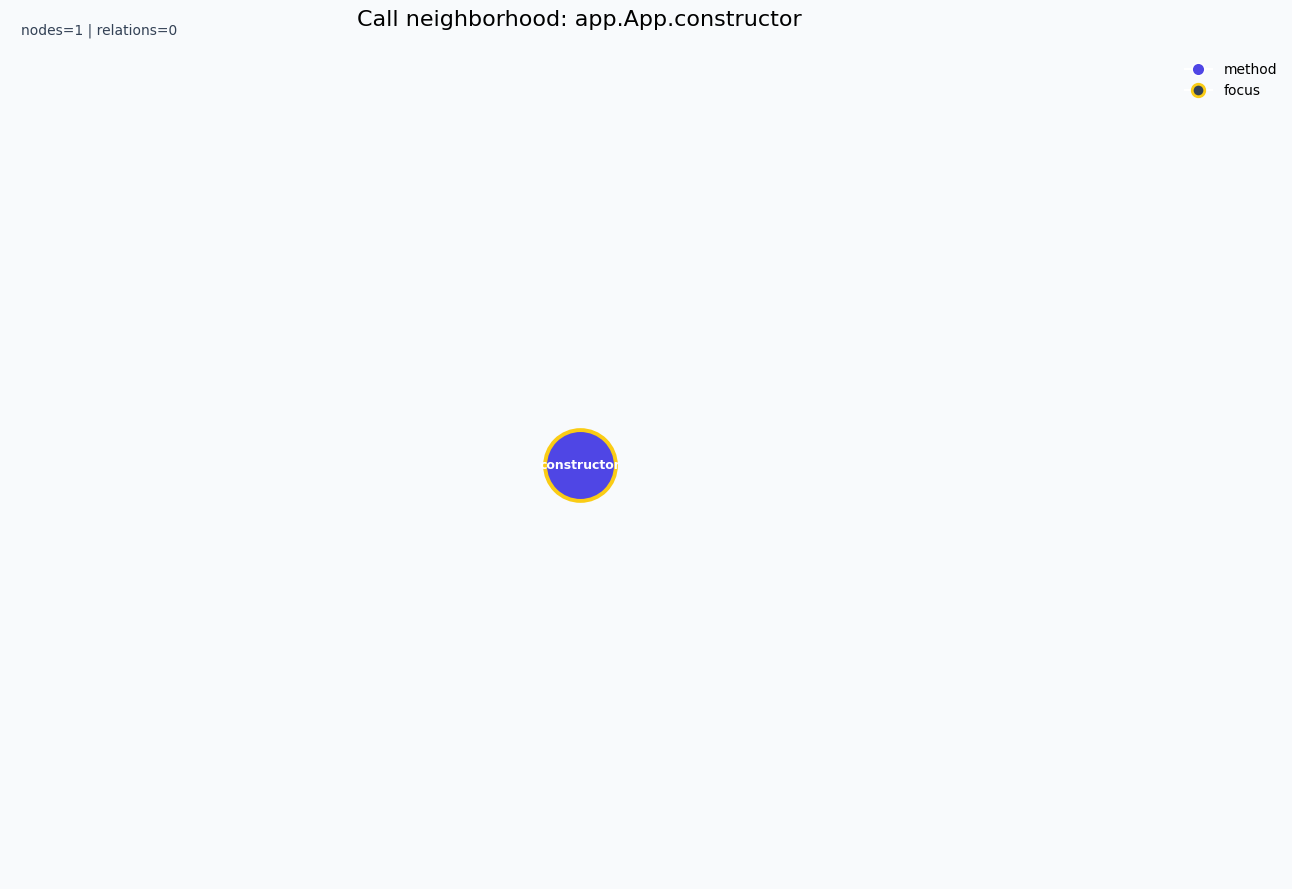

In [63]:
plot_call_neighborhood(
    graph,
    function_query=focus_function,
    depth=focus_depth,
    include_callers=include_callers,
    include_callees=include_callees,
)
